In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [3]:


uploaded = files.upload()

Saving dermatology_database_1.csv to dermatology_database_1 (1).csv


In [4]:


file_name = list(uploaded.keys())[0]


df = pd.read_csv(
    file_name,
    header=None,
    na_values="?"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (367, 35)


,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
1,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
2,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
3,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
4,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1


In [5]:
# Create feature names

feature_names = [
    "erythema",
    "scaling",
    "definite_borders",
    "itching",
    "koebner_phenomenon",
    "polygonal_papules",
    "follicular_papules",
    "oral_mucosal_involvement",
    "knee_and_elbow_involvement",
    "scalp_involvement",
    "family_history",
    "melanin_incontinence",
    "eosinophils_in_the_infiltrate",
    "PNL_infiltrate",
    "fibrosis_of_the_papillary_dermis",
    "exocytosis",
    "acanthosis",
    "hyperkeratosis",
    "parakeratosis",
    "clubbing_of_the_rete_ridges",
    "elongation_of_the_rete_ridges",
    "thinning_of_the_suprapapillary_epidermis",
    "spongiform_pustule",
    "munro_microabcess",
    "focal_hypergranulosis",
    "disappearance_of_the_granular_layer",
    "vacuolisation_and_damage_of_basal_layer",
    "spongiosis",
    "saw_tooth_appearance_of_retes",
    "follicular_horn_plug",
    "perifollicular_parakeratosis",
    "inflammatory_monoluclear_infiltrate",
    "band_like_infiltrate",
    "age"
]

# Add target column
column_names = feature_names + ["class"]

# Assign column names
df.columns = column_names

print("Number of rows and columns:", df.shape)

df.head()

Number of rows and columns: (367, 35)


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
0,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
1,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
2,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
3,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
4,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1


In [6]:
# Display basic information

print("Dataset Information:\n")

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  367 non-null    object
 1   scaling                                   367 non-null    object
 2   definite_borders                          367 non-null    object
 3   itching                                   367 non-null    object
 4   koebner_phenomenon                        367 non-null    object
 5   polygonal_papules                         367 non-null    object
 6   follicular_papules                        367 non-null    object
 7   oral_mucosal_involvement                  367 non-null    object
 8   knee_and_elbow_involvement                367 non-null    object
 9   scalp_involvement                         367 non-null    object
 10  family_history              

In [7]:
# Display number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display first five rows
print("\nFirst five rows:")
display(df.head())

# Display last five rows
print("\nLast five rows:")
display(df.tail())

Number of rows: 367
Number of columns: 35

First five rows:


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
0,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
1,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
2,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
3,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
4,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1



Last five rows:


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
362,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
363,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
364,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
365,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3
366,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35,1


In [8]:
# Convert all feature columns to numeric values

df[feature_names] = df[feature_names].apply(
    pd.to_numeric,
    errors="coerce"
)

# Convert target column to numeric
df["class"] = pd.to_numeric(
    df["class"],
    errors="coerce"
)

# Summary statistics for all features

summary_statistics = df[feature_names].describe().T

# Add median
summary_statistics["median"] = df[feature_names].median()

# Rearrange columns
summary_statistics = summary_statistics[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

display(summary_statistics)

,count,mean,median,std,min,25%,50%,75%,max
erythema,366.0,2.068306,2.0,0.664753,0.0,2.0,2.0,2.00,3.0
scaling,366.0,1.795082,2.0,0.701527,0.0,1.0,2.0,2.00,3.0
definite_borders,366.0,1.549180,2.0,0.907525,0.0,1.0,2.0,2.00,3.0
itching,366.0,1.366120,1.0,1.138299,0.0,0.0,1.0,2.00,3.0
koebner_phenomenon,366.0,0.633880,0.0,0.908016,0.0,0.0,0.0,1.00,3.0
polygonal_papules,366.0,0.448087,0.0,0.957327,0.0,0.0,0.0,0.00,3.0
follicular_papules,366.0,0.166667,0.0,0.570588,0.0,0.0,0.0,0.00,3.0
oral_mucosal_involvement,366.0,0.377049,0.0,0.834147,0.0,0.0,0.0,0.00,3.0
knee_and_elbow_involvement,366.0,0.614754,0.0,0.982979,0.0,0.0,0.0,1.00,3.0
scalp_involvement,366.0,0.519126,0.0,0.905639,0.0,0.0,0.0,1.00,3.0


In [9]:
# Count missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:\n")
display(missing_values[missing_values > 0])

print("Total missing values:", df.isnull().sum().sum())

Missing values in each column:



,0
erythema,1
scaling,1
definite_borders,1
itching,1
koebner_phenomenon,1
polygonal_papules,1
follicular_papules,1
oral_mucosal_involvement,1
knee_and_elbow_involvement,1
scalp_involvement,1


Total missing values: 43


In [10]:
# Count duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (367, 35)


In [12]:
# Remove rows where the target class is missing

df = df.dropna(subset=["class"]).reset_index(drop=True)

# Replace missing feature values with the median of each feature

imputer = SimpleImputer(strategy="median")

df[feature_names] = imputer.fit_transform(
    df[feature_names]
)

print("Total missing values after handling:")
print(df.isnull().sum().sum())

Total missing values after handling:
0


In [13]:
# Calculate the number of potential outliers in each feature

outlier_counts = {}

for column in feature_names:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_counts[column] = len(outliers)

outlier_summary = pd.DataFrame(
    list(outlier_counts.items()),
    columns=["Feature", "Number_of_Outliers"]
)

display(
    outlier_summary.sort_values(
        by="Number_of_Outliers",
        ascending=False
    )
)

,Feature,Number_of_Outliers
16,acanthosis,156
0,erythema,151
23,munro_microabcess,80
32,band_like_infiltrate,77
28,saw_tooth_appearance_of_retes,72
26,vacuolisation_and_damage_of_basal_layer,72
24,focal_hypergranulosis,71
22,spongiform_pustule,70
11,melanin_incontinence,70
5,polygonal_papules,69


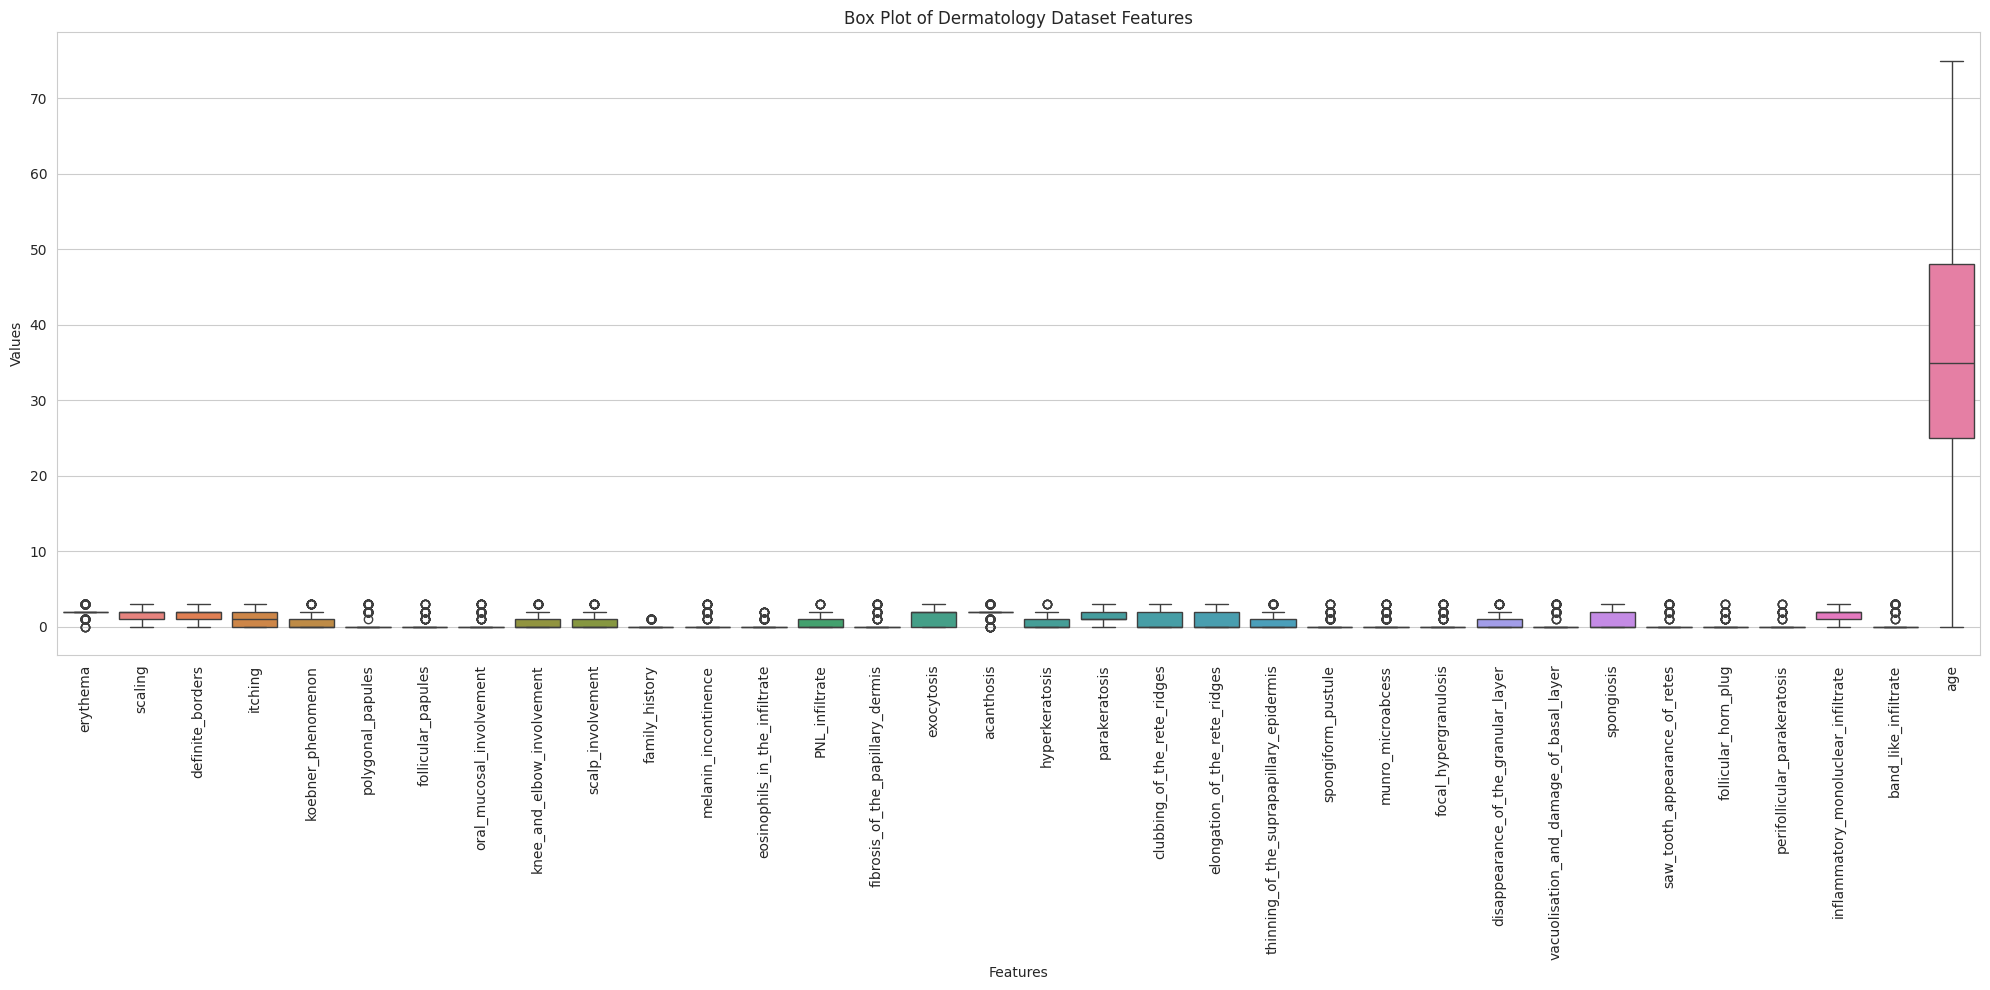

In [14]:
# Create box plots for all features

plt.figure(figsize=(20, 10))

sns.boxplot(data=df[feature_names])

plt.title("Box Plot of Dermatology Dataset Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

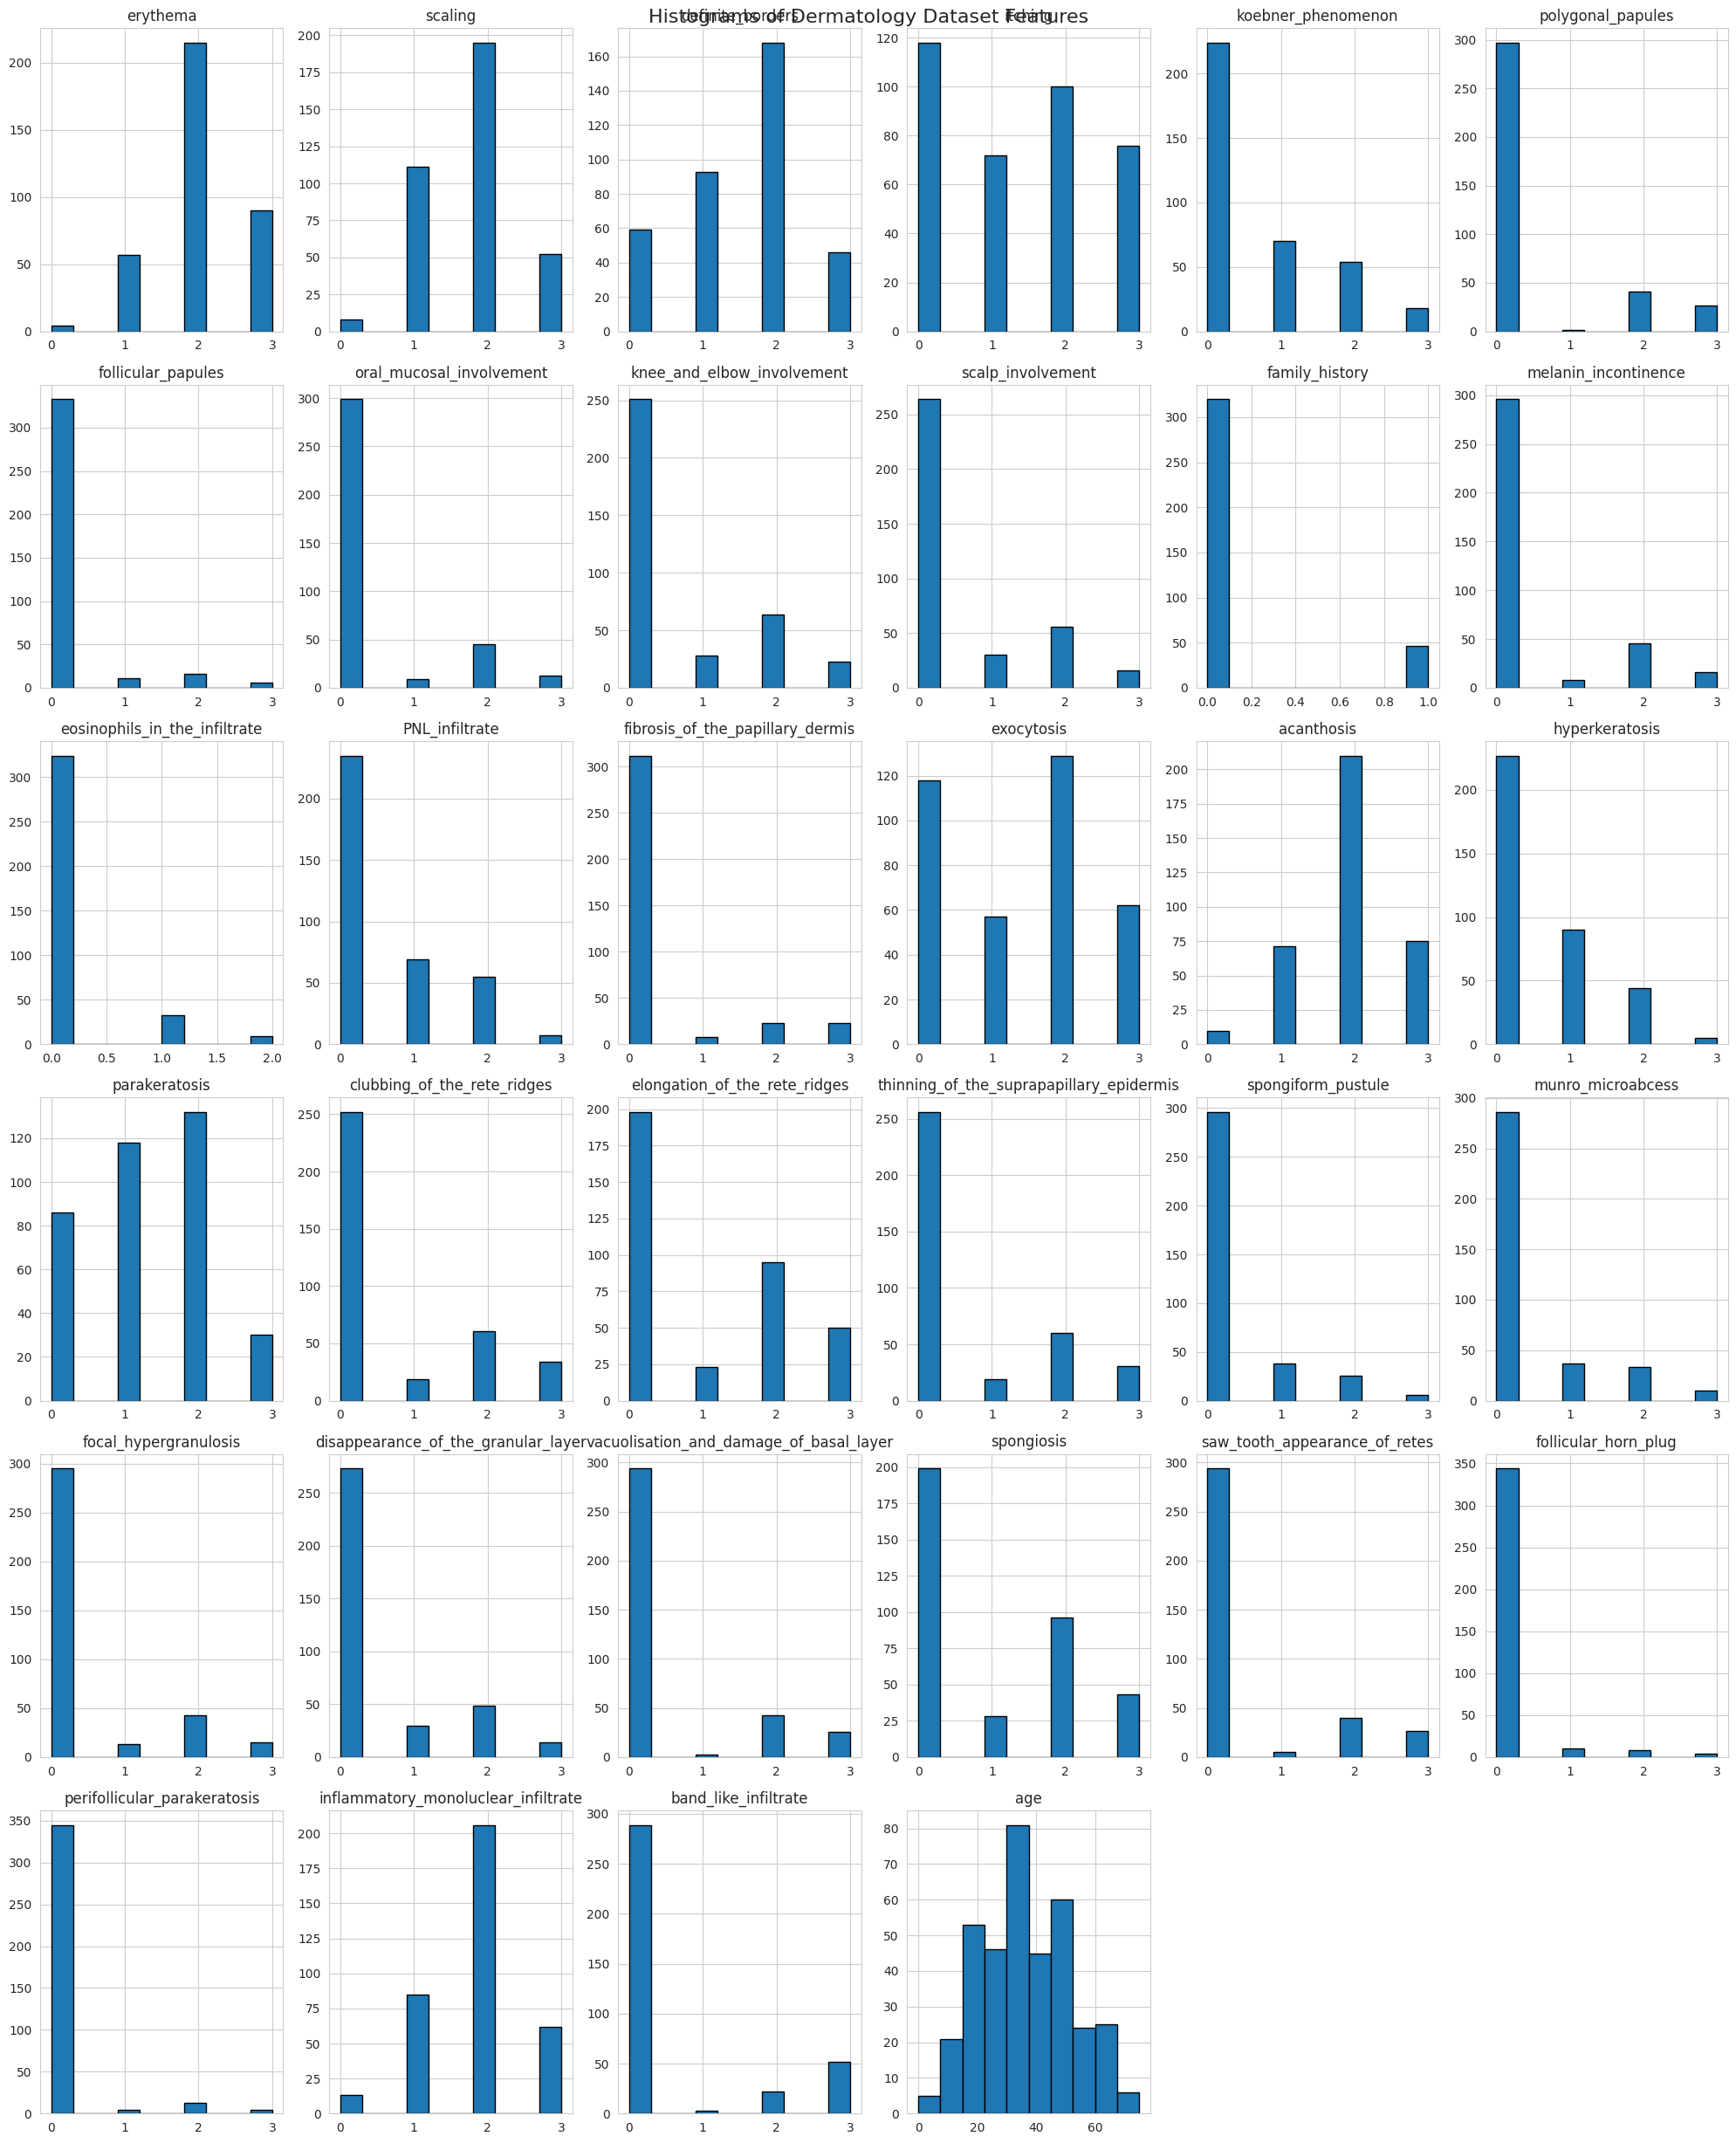

In [15]:
# Plot histograms for all features

df[feature_names].hist(
    figsize=(20, 25),
    bins=10,
    edgecolor="black"
)

plt.suptitle(
    "Histograms of Dermatology Dataset Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

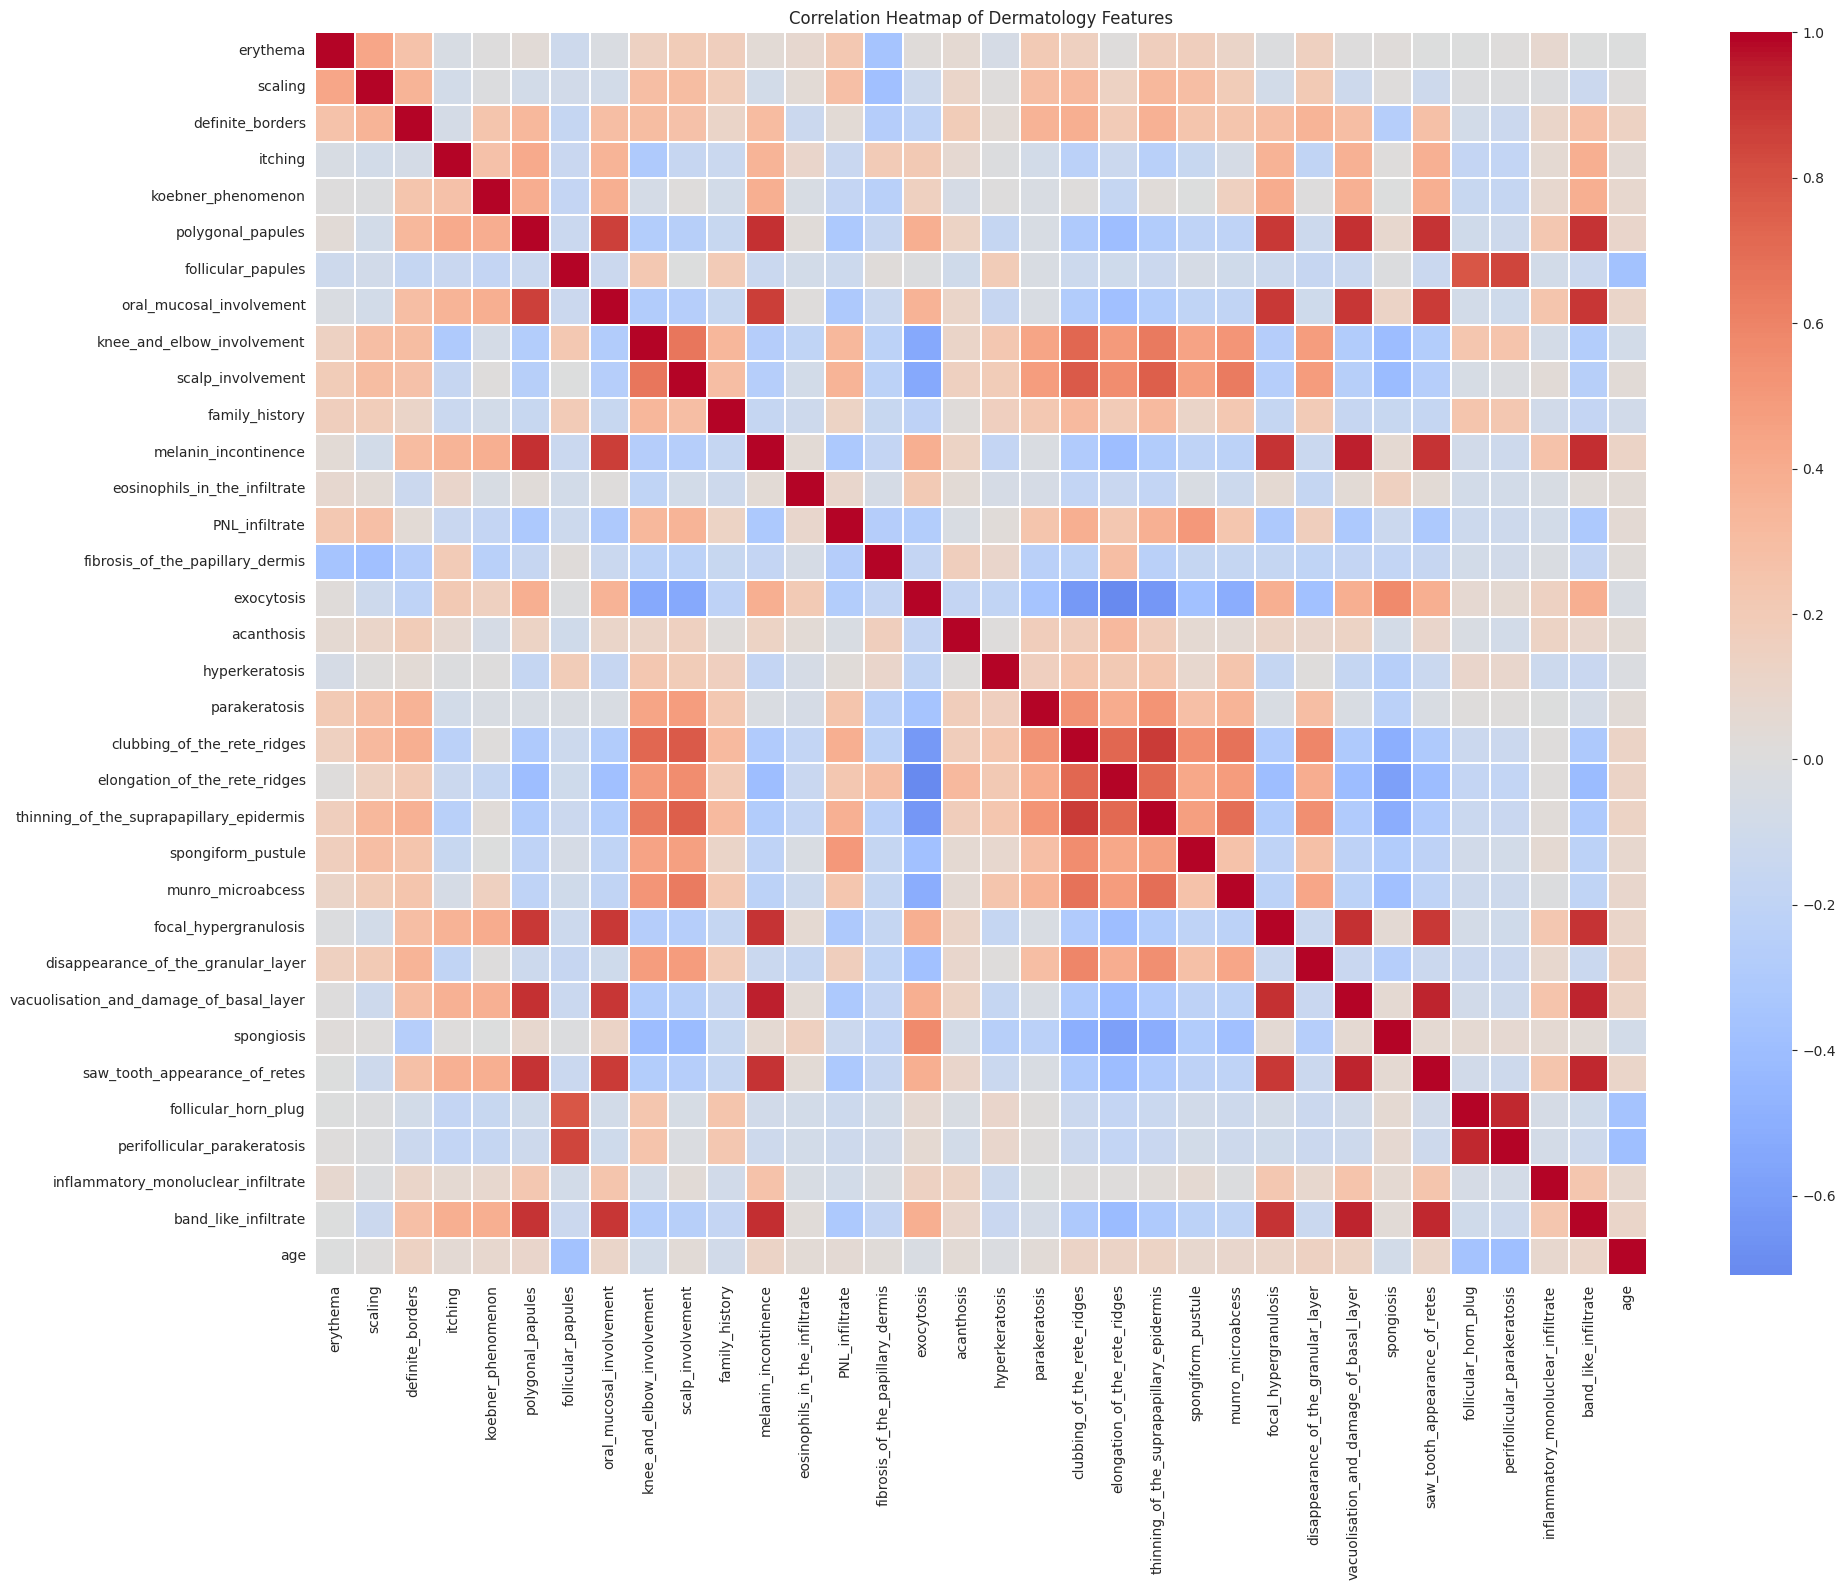

In [16]:
# Calculate feature correlations

correlation_matrix = df[feature_names].corr()

# Plot heatmap

plt.figure(figsize=(20, 16))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap of Dermatology Features")

plt.tight_layout()
plt.show()

In [17]:
# Count the number of samples in each class

class_counts = df["class"].value_counts().sort_index()

print("Class distribution:\n")
display(class_counts)

Class distribution:



,count
class,
1.0,112
2.0,61
3.0,72
4.0,49
5.0,52
6.0,20


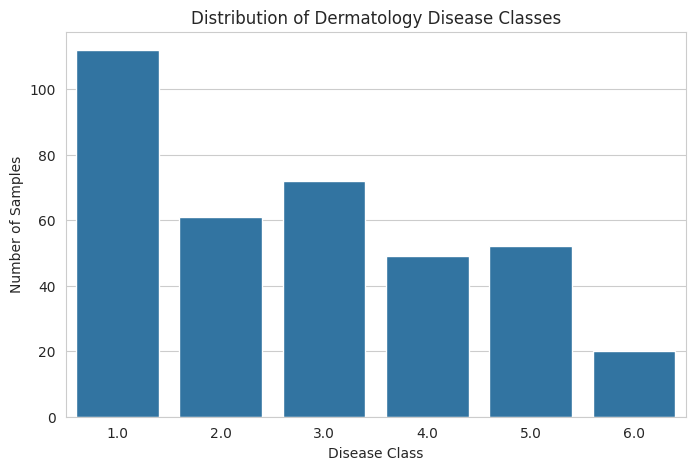

In [18]:
# Plot class distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="class",
    order=sorted(df["class"].unique())
)

plt.title("Distribution of Dermatology Disease Classes")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")

plt.show()

In [19]:
# Calculate class percentages

class_percentages = (
    df["class"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Class distribution in percentage:\n")

display(class_percentages)

Class distribution in percentage:



,proportion
class,
1.0,30.601093
2.0,16.666667
3.0,19.672131
4.0,13.387978
5.0,14.207650
6.0,5.464481


In [20]:
# Separate input features and target variable

X = df[feature_names]

y = df["class"].astype(int)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(sorted(y.unique()))

Features shape: (366, 34)
Target shape: (366,)

Target classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [21]:
from sklearn.preprocessing import LabelEncoder

# Encode target variable

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y_encoded))

Original classes: [1 2 3 4 5 6]
Encoded classes: [0 1 2 3 4 5]


In [22]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (292, 34)
Testing data shape: (74, 34)


In [23]:
# Check class distribution in training and testing sets

print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training class distribution:
0    89
1    49
2    57
3    39
4    42
5    16
Name: count, dtype: int64

Testing class distribution:
0    23
1    12
2    15
3    10
4    10
5     4
Name: count, dtype: int64


In [24]:
# Standardize features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training features standardized successfully.")
print("Testing features standardized successfully.")

Training features standardized successfully.
Testing features standardized successfully.


In [25]:
# Define multiclass classification models

models = {

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
}

In [26]:
# Train all models

trained_models = {}

for model_name, model in models.items():

    model.fit(X_train_scaled, y_train)

    trained_models[model_name] = model

    print(model_name, "trained successfully.")

KNN trained successfully.
Logistic Regression trained successfully.
Random Forest trained successfully.
SVM trained successfully.


In [27]:
# Generate predictions for all models

predictions = {}

probabilities = {}

for model_name, model in trained_models.items():

    # Predicted class labels
    y_pred = model.predict(X_test_scaled)

    # Predicted probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test_scaled)

    predictions[model_name] = y_pred

    probabilities[model_name] = y_prob

print("Predictions generated for all models.")

Predictions generated for all models.


In [28]:
# Evaluate all models

results = []

for model_name in trained_models.keys():

    y_pred = predictions[model_name]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.905405,0.919305,0.905405,0.908094
1,Logistic Regression,0.959459,0.968815,0.959459,0.960642
2,Random Forest,0.959459,0.960688,0.959459,0.959543
3,SVM,0.972973,0.977477,0.972973,0.972973


In [29]:
# Display detailed classification reports

for model_name in trained_models.keys():

    print("\n" + "=" * 70)
    print("Classification Report:", model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[model_name],
            target_names=[
                str(c) for c in label_encoder.classes_
            ],
            zero_division=0
        )
    )


Classification Report: KNN
              precision    recall  f1-score   support

           1       1.00      0.96      0.98        23
           2       0.80      0.67      0.73        12
           3       1.00      0.93      0.97        15
           4       0.64      0.90      0.75        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.91        74
   macro avg       0.91      0.91      0.90        74
weighted avg       0.92      0.91      0.91        74


Classification Report: Logistic Regression
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      0.93      0.97        15
           4       0.77      1.00      0.87        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    a

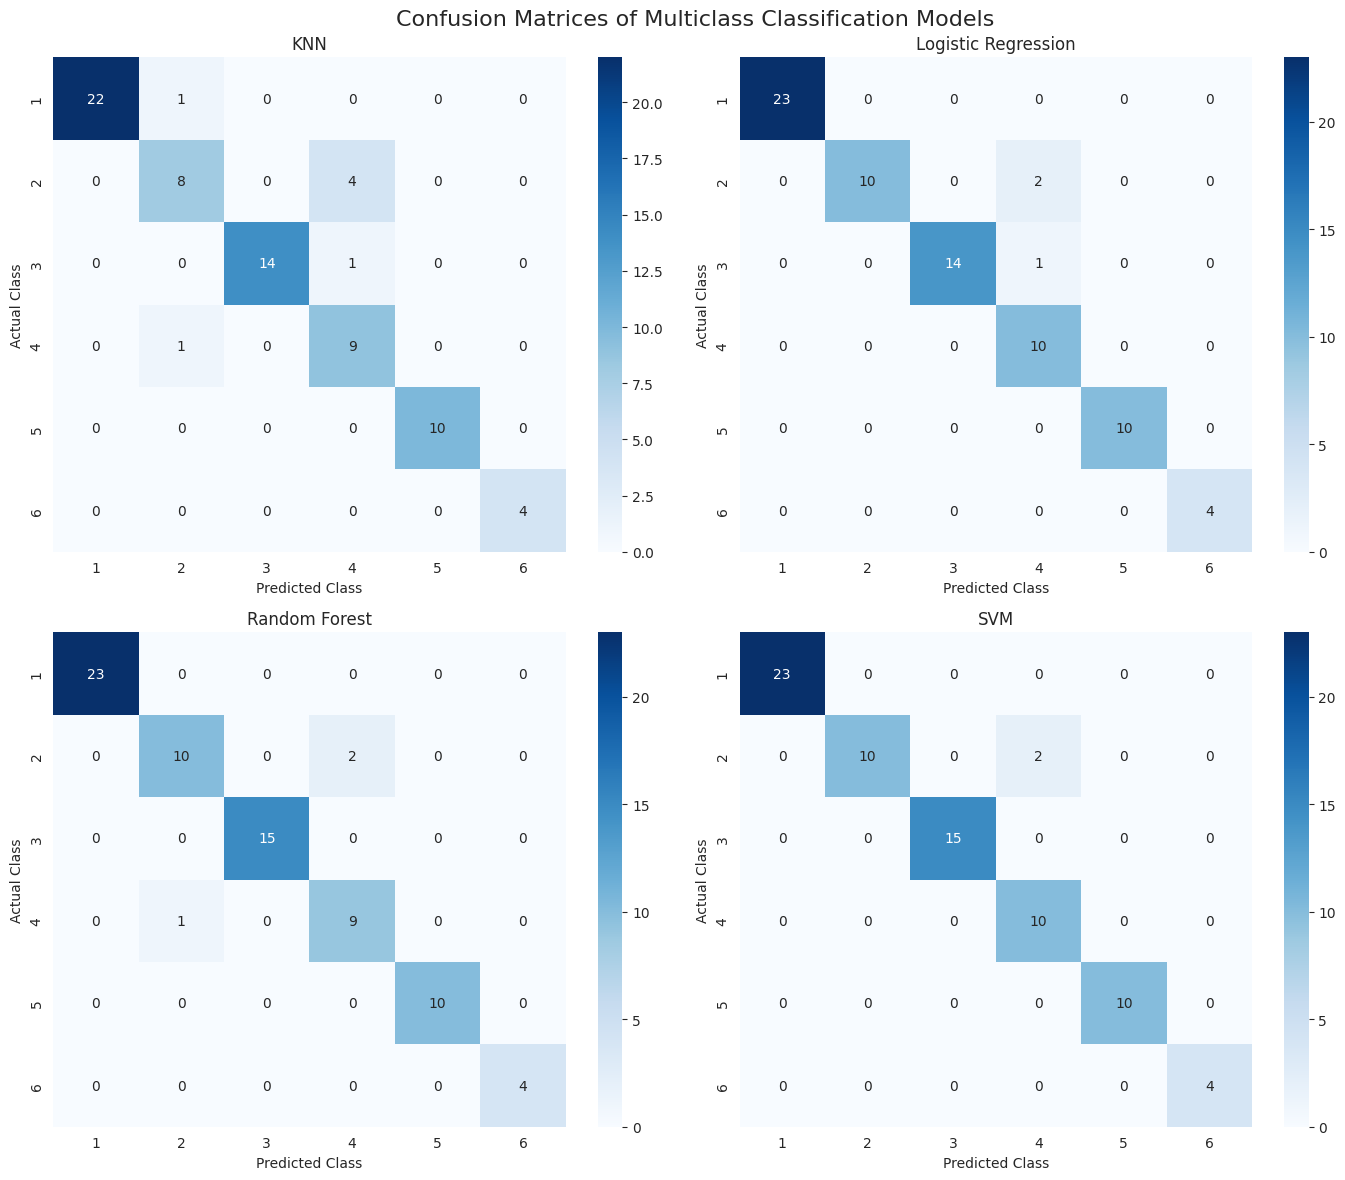

In [30]:
# Plot confusion matrices for all models

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12)
)

axes = axes.ravel()

class_labels = [
    str(c) for c in label_encoder.classes_
]

for ax, (model_name, y_pred) in zip(
    axes,
    predictions.items()
):

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

plt.suptitle(
    "Confusion Matrices of Multiclass Classification Models",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [31]:
# Calculate multiclass ROC-AUC scores

auc_results = []

for model_name in trained_models.keys():

    y_prob = probabilities[model_name]

    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    auc_results.append({
        "Model": model_name,
        "Multiclass ROC-AUC": roc_auc
    })

auc_df = pd.DataFrame(auc_results)

display(auc_df)

,Model,Multiclass ROC-AUC
0,KNN,0.987076
1,Logistic Regression,0.999135
2,Random Forest,0.998495
3,SVM,0.998284


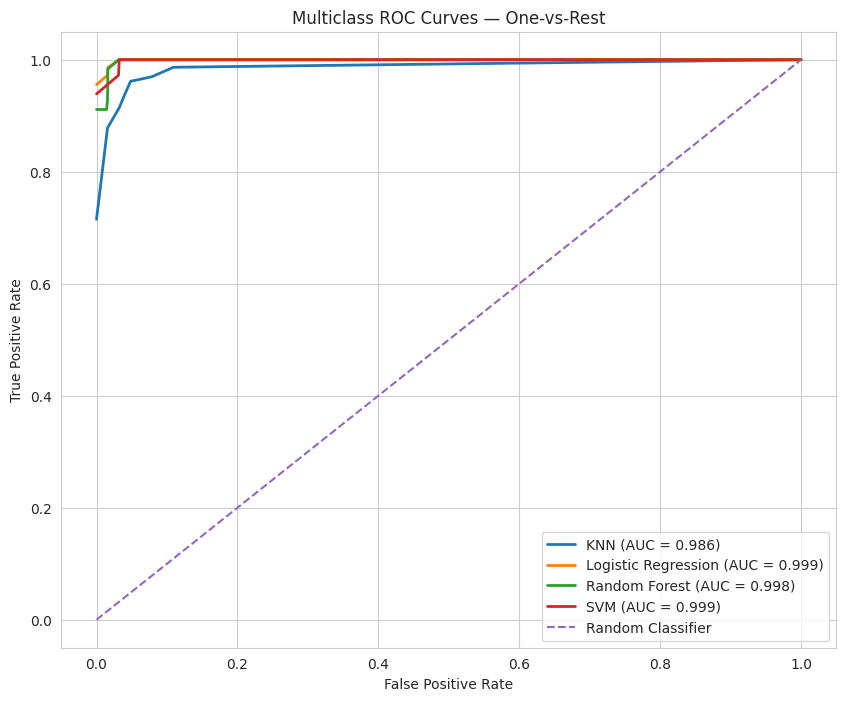

In [32]:
# Binarize target labels for multiclass ROC curves

n_classes = len(label_encoder.classes_)

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(n_classes)
)

plt.figure(figsize=(10, 8))

for model_name in trained_models.keys():

    y_prob = probabilities[model_name]

    # Calculate macro-average ROC curve

    fpr = {}
    tpr = {}

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

    # Combine all classes to calculate macro-average curve

    all_fpr = np.unique(
        np.concatenate(
            [fpr[i] for i in range(n_classes)]
        )
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):

        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= n_classes

    macro_auc = auc(
        all_fpr,
        mean_tpr
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {macro_auc:.3f})"
    )

# Reference line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Multiclass ROC Curves — One-vs-Rest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True)

plt.show()

In [33]:
# Merge all evaluation metrics

final_results = results_df.merge(
    auc_df,
    on="Model"
)

# Sort models by F1-score

final_results = final_results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

display(final_results)

,Model,Accuracy,Precision,Recall,F1-Score,Multiclass ROC-AUC
0,SVM,0.972973,0.977477,0.972973,0.972973,0.998284
1,Logistic Regression,0.959459,0.968815,0.959459,0.960642,0.999135
2,Random Forest,0.959459,0.960688,0.959459,0.959543,0.998495
3,KNN,0.905405,0.919305,0.905405,0.908094,0.987076


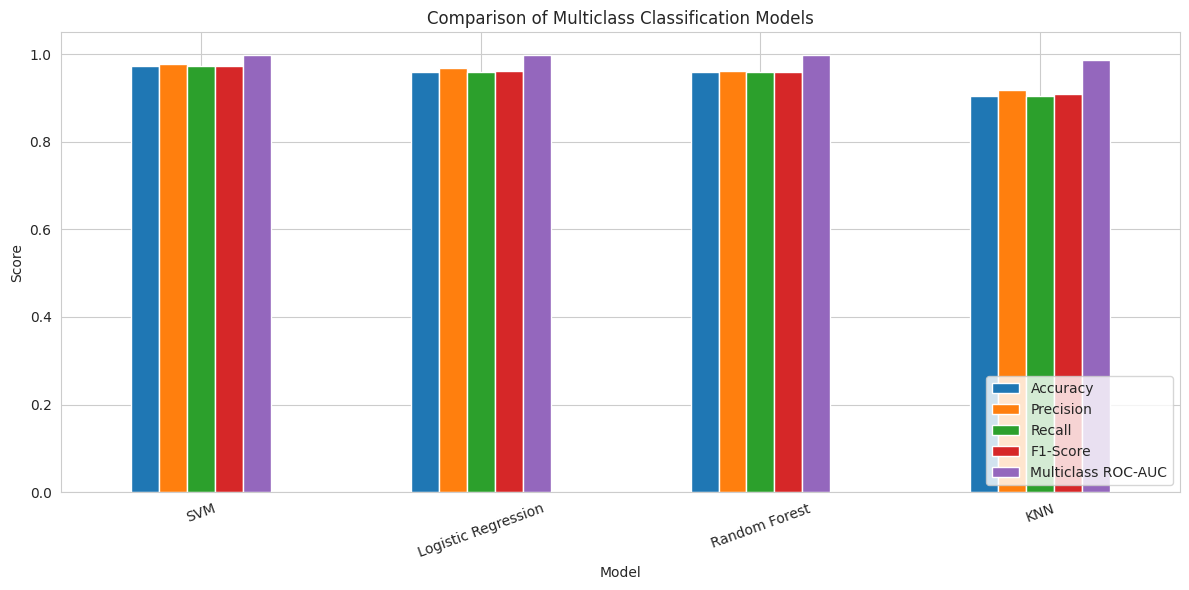

In [34]:
# Plot comparison of model evaluation metrics

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Multiclass ROC-AUC"
]

final_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Multiclass Classification Models")
plt.ylabel("Score")
plt.xlabel("Model")

plt.ylim(0, 1.05)
plt.xticks(rotation=20)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [35]:
# Identify the best model based on F1-score

best_model_name = final_results.iloc[0]["Model"]

print("Best-performing model:", best_model_name)

print("\nPerformance of the best model:\n")

display(
    final_results[
        final_results["Model"] == best_model_name
    ]
)

Best-performing model: SVM

Performance of the best model:



,Model,Accuracy,Precision,Recall,F1-Score,Multiclass ROC-AUC
0,SVM,0.972973,0.977477,0.972973,0.972973,0.998284
